# CPPN — Compositional Pattern-Producing Networks
  
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NFAsylum/cppn/blob/main/notebooks/cppn_demo.ipynb)

Interactive demo of CPPN implementation — neural network as implicit image representation. Two modes shown below: random procedural art (untrained weights) and single-image overfit (compression demo).

See repo for full details and limitations:
[github.com/NFAsylum/cppn](https://github.com/NFAsylum/cppn).

In [1]:
%cd /content/
!rm -rf cppn
!git clone https://github.com/NFAsylum/cppn.git
%cd /content/cppn
!pip install -q -r requirements.txt

import sys
sys.path.insert(0, '.')

/content
Cloning into 'cppn'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 87 (delta 22), reused 68 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 21.92 MiB | 22.16 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/cppn


## Random mode: procedural art from untrained weights

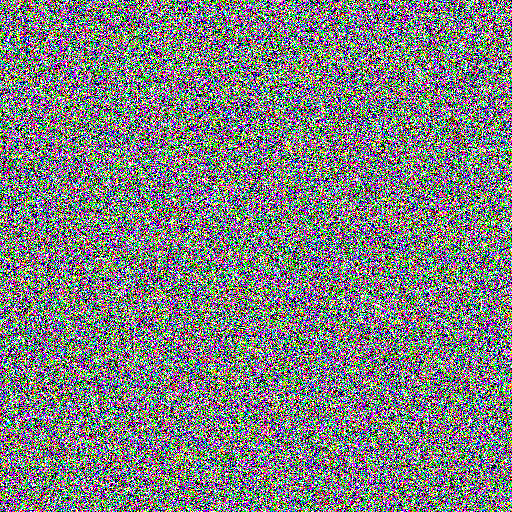

In [2]:
from cppn import CPPN
from render import render_image
import torch, random

model = CPPN(input_dim=7, weight_sigma=random.uniform(0.5, 2.0))
image = render_image(model, 512, 512, r_strength=2.0, tileable=False)
image # Colab renders PIL Image inline

## Training mode (reduced for fast training in Colab)

In [3]:
from train import load_target, build_coords, train, snapshot, report_compression
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Use cloned image as target
target = load_target('target/cppn-target-image.png', 256).to(device)
coords = build_coords(256, tileable=False).to(device)
model = CPPN(input_dim=7, output_channels=3).to(device)

# 1000 iters for fast training (instead of 3000)
import os
os.makedirs('training_output', exist_ok=True)

start = time.perf_counter()
losses = train(model, target, coords, iterations=1000, lr=1e-3, snapshot_iters=[0, 100, 500, 999], size=256, output_folder='training_output')
elapsed = time.perf_counter() - start
print(f'Training finished in {elapsed:.1f}s')

Using device: cuda
Finished iter 0/1000, loss: 0.351669
Finished iter 100/1000, loss: 0.299700
Finished iter 200/1000, loss: 0.224940
Finished iter 300/1000, loss: 0.152140
Finished iter 400/1000, loss: 0.095509
Finished iter 500/1000, loss: 0.048789
Finished iter 600/1000, loss: 0.029180
Finished iter 700/1000, loss: 0.021387
Finished iter 800/1000, loss: 0.020320
Finished iter 900/1000, loss: 0.019769
Training finished in 20.5s


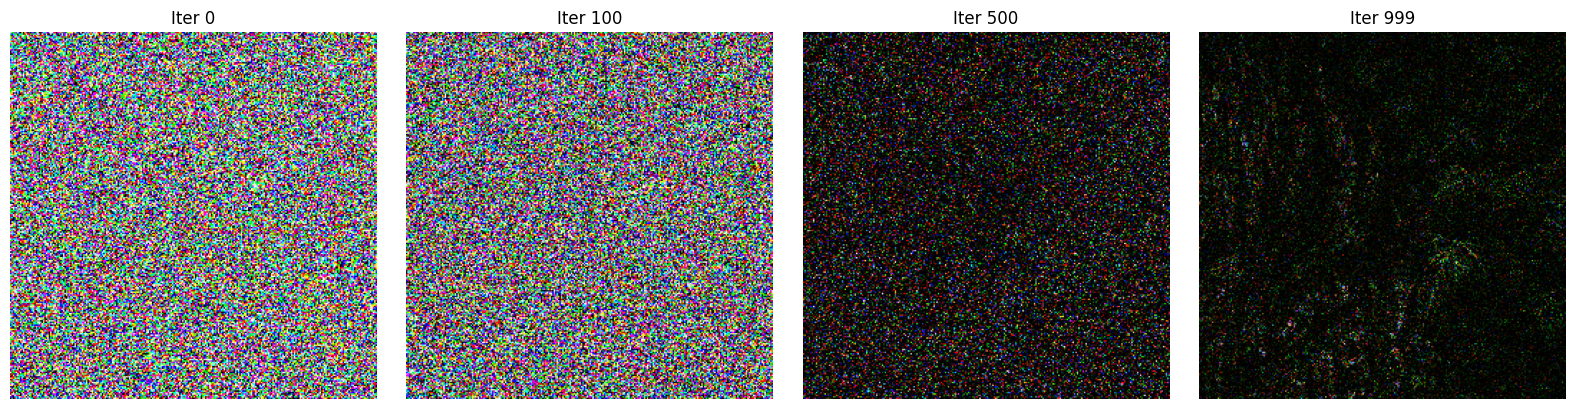

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, it in zip(axes, [0, 100, 500, 999]):
    ax.imshow(Image.open(f'training_output/snapshot_iter_{it:05d}.png'))
    ax.set_title(f'Iter {it}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
report_compression(model, 'target/cppn-target-image.png', losses[-1], 'training_output', duration=elapsed)

Model size: 100.3 KB
Target size: 1919.7 KB
Ratio: 19.15x
PSNR: 17.21 dB
Training duration: 20.5s


## Notes

This demo uses reduced training (1000 iterations vs 3000 in the repo) for faster Colab execution. PSNR will be lower than the recommended config shown in the README.

For full results and limitations (mode collapse at deeper architectures), see the [repo README](https://github.com/NFAsylum/cppn)